In [1]:
%config InteractiveShell.ast_node_interactivity='last_expr_or_assign'  # always print last expr.
%config InlineBackend.figure_format = 'svg'
%load_ext autoreload
%autoreload 2

In [2]:
import pickle
import xarray

import numpy as np
from zipfile import ZipFile

import linodenet
import matplotlib.pyplot as plt
import torch


from tqdm import tqdm, trange
from pathlib import Path
import pandas
from pandas import DataFrame

In [3]:
df = pandas.read_hdf(Path.cwd().parent.joinpath('data/some_data_from_db.h5'))
df = df.drop(columns="unit")

measurement_id   Acetate  Acid  Base  \
experiment_id measurement_time                                         
8627          0.0                     13418568       NaN   NaN   NaN   
              0.0                     13418576       NaN   NaN   NaN   
              0.0                     13418616  0.156787   NaN   NaN   
              0.0                     13418624  0.156787   NaN   NaN   
              950255.0                13400808       NaN   NaN   NaN   
...                                        ...       ...   ...   ...   
8664          28000.0                 13585193       NaN   NaN   NaN   
              28009.0                 13585217       NaN   NaN   NaN   
              28010.0                 13585241       NaN   NaN   NaN   
              1208063.0               13624609       NaN   NaN   NaN   
              1208243.0               13624633       NaN   NaN   NaN   

                                Cumulated_feed_volume_acetate  \
experiment_id measurement_time                                  
8627          0.0                                         NaN   
              0.0                                         NaN   
              0.0                                         NaN   
              0.0                                         NaN   
              950255.0                                    NaN   
...                                                       ...   
8664          28000.0                                     NaN   
              28009.0                                     NaN   
              28010.0                                     NaN   
              1208063.0                                   NaN   
              1208243.0                                   NaN   

                                Cumulated_feed_volume_glucose  \
experiment_id measurement_time                                  
8627          0.0                                         NaN   
              0.0                                         NaN   
              0.0                                         NaN   
              0.0                                         NaN   
              950255.0                                    NaN   
...                                                       ...   
8664          28000.0                                     NaN   
              28009.0                                     NaN   
              28010.0                                     NaN   
              1208063.0                                   NaN   
              1208243.0                                   NaN   

                                Cumulated_feed_volume_medium        DOT  \
experiment_id measurement_time                                            
8627          0.0                                        NaN        NaN   
              0.0                                        NaN        NaN   
              0.0                                        NaN        NaN   
              0.0                                        NaN        NaN   
              950255.0                                   NaN   7.460000   
...                                                      ...        ...   
8664          28000.0                                    NaN        NaN   
              28009.0                                    NaN  40.330002   
              28010.0                                    NaN        NaN   
              1208063.0                                  NaN        NaN   
              1208243.0                                  NaN        NaN   

                                Enzyme_addition    Glucose   OD600  \
experiment_id measurement_time                                       
8627          0.0                           NaN  -7.206886     NaN   
              0.0                           NaN -14.505053     NaN   
              0.0                           NaN        NaN     NaN   
              0.0                           NaN        NaN     NaN   
       

In [16]:
data = df.loc[8627].reset_index()

,measurement_time,measurement_id,Acetate,Acid,Base,Cumulated_feed_volume_acetate,Cumulated_feed_volume_glucose,Cumulated_feed_volume_medium,DOT,Enzyme_addition,Glucose,OD600,Probe_Volume,pH
0,0.0,13418568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-7.206886,NaN,NaN,NaN
1,0.0,13418576,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-14.505053,NaN,NaN,NaN
2,0.0,13418616,0.156787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,13418624,0.156787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,950255.0,13400808,NaN,NaN,NaN,NaN,NaN,NaN,7.46,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2970,1267376.0,13471800,NaN,NaN,NaN,NaN,NaN,NaN,2.78,NaN,NaN,NaN,NaN,NaN
2971,1267376.0,13471824,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.55
2972,1267436.0,13471848,NaN,NaN,NaN,NaN,NaN,NaN,2.53,NaN,NaN,NaN,NaN,NaN
2973,1267436.0,13471872,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.55


In [101]:
slc = data.set_index("measurement_time").iloc[[0,1,2,7,99,101]].iloc[:, [1,5,4]]

,Acetate,Cumulated_feed_volume_glucose,Cumulated_feed_volume_acetate
measurement_time,,,
0.0,NaN,NaN,NaN
0.0,NaN,NaN,NaN
0.0,0.156787,NaN,NaN
950329.0,NaN,NaN,NaN
954260.0,NaN,NaN,NaN
954380.0,NaN,NaN,NaN


In [124]:
full = data.set_index(["measurement_time", "measurement_id"])

Acetate  Acid  Base  \
measurement_time measurement_id                         
0.0              13418568             NaN   NaN   NaN   
                 13418576             NaN   NaN   NaN   
                 13418616        0.156787   NaN   NaN   
                 13418624        0.156787   NaN   NaN   
950255.0         13400808             NaN   NaN   NaN   
...                                   ...   ...   ...   
1267376.0        13471800             NaN   NaN   NaN   
                 13471824             NaN   NaN   NaN   
1267436.0        13471848             NaN   NaN   NaN   
                 13471872             NaN   NaN   NaN   
1273440.0        13479240             NaN   NaN   NaN   

                                 Cumulated_feed_volume_acetate  \
measurement_time measurement_id                                  
0.0              13418568                                  NaN   
                 13418576                                  NaN   
                 13418616                                  NaN   
                 13418624                                  NaN   
950255.0         13400808                                  NaN   
...                                                        ...   
1267376.0        13471800                                  NaN   
                 13471824                                  NaN   
1267436.0        13471848                                  NaN   
                 13471872                                  NaN   
1273440.0        13479240                                  NaN   

                                 Cumulated_feed_volume_glucose  \
measurement_time measurement_id                                  
0.0              13418568                                  NaN   
                 13418576                                  NaN   
                 13418616                                  NaN   
                 13418624                                  NaN   
950255.0         13400808                                  NaN   
...                                                        ...   
1267376.0        13471800                                  NaN   
                 13471824                                  NaN   
1267436.0        13471848                                  NaN   
                 13471872                                  NaN   
1273440.0        13479240                                  NaN   

                                 Cumulated_feed_volume_medium   DOT  \
measurement_time measurement_id                                       
0.0              13418568                                 NaN   NaN   
                 13418576                                 NaN   NaN   
                 13418616                                 NaN   NaN   
                 13418624                                 NaN   NaN   
950255.0         13400808                                 NaN  7.46   
...                                                       ...   ...   
1267376.0        13471800                                 NaN  2.78   
                 13471824                                 NaN   NaN   
1267436.0        13471848                                 NaN  2.53   
                 13471872                                 NaN   NaN   
1273440.0        13479240                                 NaN   NaN   

                                 Enzyme_addition    Glucose     OD600  \
measurement_time measurement_id                                         
0.0              13418568                    NaN  -7.206886       NaN   
                 13418576                    NaN -14.505053       NaN   
                 13418616                    NaN        NaN       NaN   
                 13418624                    NaN        NaN       NaN   
950255.0         13400808                    NaN        NaN       NaN   
...                                          ...        ...       ...   
1267376.0        13471800                    NaN        NaN       

In [131]:
xarray.DataArray(full, dims=["obs time", "obs val"], name="run 1").to_dataframe().memory_usage()

Index    347984
run 1    285600
dtype: int64

In [127]:
xarray.Dataset(coords = {"full":xarray.DataArray(full), "slc":xarray.DataArray(slc)})

ValueError: conflicting MultiIndex level name(s):
'measurement_time' (dim_0), (measurement_time)

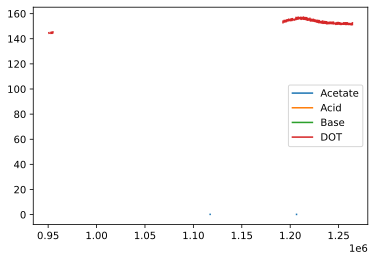

In [24]:
fig, ax = plt.subplots()

for col in ("Acetate", "Acid", "Base", "DOT"):
    line = ax.plot(data["measurement_time"].iloc[6:-100], data[col].iloc[6:-100])
    
ax.legend(["Acetate", "Acid", "Base", "DOT"])

In [6]:
ds = torch.tensor(data.values)

tensor([[0.0000e+00, 1.3472e+07,        nan,  ...,        nan,        nan,
                nan],
        [1.0000e+00, 1.3472e+07,        nan,  ...,        nan,        nan,
         7.1200e+00],
        [1.0000e+01, 1.3472e+07,        nan,  ...,        nan,        nan,
                nan],
        ...,
        [2.8010e+04, 1.3585e+07,        nan,  ...,        nan,        nan,
         6.2800e+00],
        [1.2081e+06, 1.3625e+07,        nan,  ..., 2.7500e-02,        nan,
                nan],
        [1.2082e+06, 1.3625e+07,        nan,  ..., 2.7500e-02,        nan,
                nan]], dtype=torch.float64)

In [88]:
sampler = BatchSampler(SequentialSampler(ds), batch_size=32, drop_last=True)
from torch import Tensor            
def collate_list(batch: list[Tensor]) -> list[Tensor]:
    r"""Collates list of tensors as list of tensors."""
    return batch

In [93]:

dloader = DataLoader(TensorDataset(ds), batch_sampler=sampler)

idloader = iter(dloader)
next(idloader), next(idloader)



([tensor([[0.0000e+00, 1.3472e+07,        nan,        nan,        nan,        nan,
                  nan,        nan, 2.7100e+00,        nan,        nan,        nan,
                  nan,        nan],
          [1.0000e+00, 1.3472e+07,        nan,        nan,        nan,        nan,
                  nan,        nan,        nan,        nan,        nan,        nan,
                  nan, 7.1200e+00],
          [1.0000e+01, 1.3472e+07,        nan,        nan,        nan,        nan,
                  nan,        nan, 2.8500e+00,        nan,        nan,        nan,
                  nan,        nan],
          [1.1000e+01, 1.3472e+07,        nan,        nan,        nan,        nan,
                  nan,        nan,        nan,        nan,        nan,        nan,
                  nan, 7.1300e+00],
          [2.4000e+01, 1.3472e+07,        nan,        nan,        nan,        nan,
                  nan,        nan, 3.5500e+00,        nan,        nan,        nan,
                  nan,    

In [45]:
list(iter(SequentialSampler(ds)))

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,


Init signature: SequentialSampler(data_source: Sized) -> None
Docstring:     
Samples elements sequentially, always in the same order.

Args:
    data_source (Dataset): dataset to sample from
File:           ~/miniconda3/envs/kiwi/lib/python3.9/site-packages/torch/utils/data/sampler.py
Type:           type
Subclasses:     


In [27]:
dir(tsdm)

['Final',
 'Path',
 '__all__',
 '__annotations__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 'config',
 'datasets',
 'encoders',
 'file',
 'generators',
 'logger',
 'logging',
 'losses',
 'models',
 'optimizers',
 'plot',
 'random',
 'trainers',
 'util']

In [28]:
import numpy

In [29]:
dir(numpy)

['ALLOW_THREADS',
 'AxisError',
 'BUFSIZE',
 'Bytes0',
 'CLIP',
 'ComplexWarning',
 'DataSource',
 'Datetime64',
 'ERR_CALL',
 'ERR_DEFAULT',
 'ERR_IGNORE',
 'ERR_LOG',
 'ERR_PRINT',
 'ERR_RAISE',
 'ERR_WARN',
 'FLOATING_POINT_SUPPORT',
 'FPE_DIVIDEBYZERO',
 'FPE_INVALID',
 'FPE_OVERFLOW',
 'FPE_UNDERFLOW',
 'False_',
 'Inf',
 'Infinity',
 'MAXDIMS',
 'MAY_SHARE_BOUNDS',
 'MAY_SHARE_EXACT',
 'MachAr',
 'ModuleDeprecationWarning',
 'NAN',
 'NINF',
 'NZERO',
 'NaN',
 'PINF',
 'PZERO',
 'RAISE',
 'RankWarning',
 'SHIFT_DIVIDEBYZERO',
 'SHIFT_INVALID',
 'SHIFT_OVERFLOW',
 'SHIFT_UNDERFLOW',
 'ScalarType',
 'Str0',
 'Tester',
 'TooHardError',
 'True_',
 'UFUNC_BUFSIZE_DEFAULT',
 'UFUNC_PYVALS_NAME',
 'Uint64',
 'VisibleDeprecationWarning',
 'WRAP',
 '_NoValue',
 '_UFUNC_API',
 '__NUMPY_SETUP__',
 '__all__',
 '__builtins__',
 '__cached__',
 '__config__',
 '__deprecated_attrs__',
 '__dir__',
 '__doc__',
 '__expired_functions__',
 '__file__',
 '__getattr__',
 '__git_version__',
 '__loader__',
